<a href="https://colab.research.google.com/github/MarinPedro/ThermalProject2026_HOCV/blob/gd-test/CuartaCopiaSCV_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# P1

Run this command if you want to remove your current folder

In [ ]:
%%capture
!rm -rf /content/IHTest_202104_DistStA/
%mkdir -p /content/IHTest_202104_DistStA/test_data
%cd /content

Loading some data from the 202104 collection of the Darpa Invisible Headlights dataset

In [ ]:
%%capture
!pip install spectral
!pip install awscli -q
!pip install laspy

In [ ]:
%%capture
!aws s3 sync \
  s3://ihdataset-01/IHTest_202104_DistStA/Path15_DistStA/Path15_Step16_DistStA/ \
  /content/IHTest_202104_DistStA/test_data \
  --no-sign-request \
  --exclude "*" \
  --include "*Path15_Step16_BBVISRIGHT_DistStA.hdr" \
  --include "*Path15_Step16_BBVISRIGHT_DistStA.raw" \
  --include "*LWHSI1_collect1_DistStA.hdr" \
  --include "*LWHSI1_collect1_DistStA.bsq"

In [ ]:
%%capture
! rm -rf /content/IHTest_202104_DistStA/depth_data
%cd ..
! git clone -n --depth=1 --filter=tree:0 \
  https://github.com/MarinPedro/ThermalProject2026_HOCV /content/IHTest_202104_DistStA/depth_data
%cd /content/IHTest_202104_DistStA/depth_data
! git sparse-checkout set --no-cone depth
! git checkout
%cd ..

Loading the Ecostress Spectral Library

In [ ]:
%%capture
! rm -rf /content/ecostress_spectral
%cd ..
! git clone -n --depth=1 --filter=tree:0 \
  https://github.com/MarinPedro/ThermalProject2026_HOCV /content/ecostress_spectral
%cd /content/ecostress_spectral
! git sparse-checkout set --no-cone ecostress
! git checkout

Importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import glob
import plotly.graph_objects as go
from pathlib import Path
from sklearn.cluster import KMeans
from skimage.color import rgb2gray
from sklearn.cluster import KMeans
from skimage.transform import resize

Implementing the functions used for the notebook

In [ ]:
MICROFLICK_PER_W_M2 = 100.0

def robust_image(image, low=2, high=98):
    """Normalize an image for display using percentiles."""
    lo, hi = np.percentile(image, [low, high])
    return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)

def blackbody_radiance(wavelenghts_um, temperature_k):
    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um * 1e-6

    x = (h * c) / (wavelength_m * k * temperature_k)

    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2

    return radiance_microflicks.astype(np.float32)

def crop_valid_region(img, pad_rows=2, pad_cols=8):
    """
    Automatically crops the region containing valid measurements.
    This helps prevent images with too much empty space.
    """
    valid = np.isfinite(img)

    if not valid.any():
        return img

    rows = np.where(valid.any(axis=1))[0]
    cols = np.where(valid.any(axis=0))[0]

    r0 = max(0, rows.min() - pad_rows)
    r1 = min(img.shape[0], rows.max() + pad_rows + 1)
    c0 = max(0, cols.min() - pad_cols)
    c1 = min(img.shape[1], cols.max() + pad_cols + 1)

    return img[r0:r1, c0:c1]


def plot_range_image(
    range_img,
    title="Range image LiDAR — inverse depth (No fov calibration)",
    crop=True,
    inverse_depth=False,
    percentile_clip=(2, 98),
    figsize=(20, 3),
):
    """
    Cleaner visualization of a range image.

    crop=True crops the region containing data.
    inverse_depth=True displays 1/r closeness, useful for making nearby objects stand out.
    percentile_clip prevents extremely distant points from dominating the color scale.
    """
    img = range_img.copy()

    if crop:
        img = crop_valid_region(img)

    valid = np.isfinite(img)
    if not valid.any():
        print("There aren't valid meditions to render.")
        return

    if inverse_depth:
        img_to_show = np.full_like(img, np.nan, dtype=np.float32)
        img_to_show[valid] = 1.0 / img[valid]
        label = "Closeness 1 / distance [1/m]"
    else:
        img_to_show = img
        label = "Radial distance [m]"

    vmin, vmax = np.nanpercentile(img_to_show, percentile_clip)
    img_masked = np.ma.masked_invalid(img_to_show)

    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="black")

    plt.figure(figsize=figsize)
    plt.imshow(
        img_masked,
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )
    plt.colorbar(label=label)
    plt.title(title)
    plt.xlabel("Horizontal angle / azimuth")
    plt.ylabel("Vertical angle / LiDAR channel")
    plt.tight_layout()
    plt.show()

def segmentation_maps(clusters, bbvis_image, lwhsi_image):
  num_clusters = clusters

  h, w, b = bbvis_image.shape
  X_rgb = bbvis_image[:, :, [0, 1, 2]].reshape(-1, 3)

  kmeans_rgb = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
  labels_rgb = kmeans_rgb.fit_predict(X_rgb)

  rgb_centers = kmeans_rgb.cluster_centers_

  rgb_brightness = rgb_centers.mean(axis=1)
  cluster_order_rgb = np.argsort(rgb_brightness)[::-1]

  h2, w2, b2 = lwhsi_image.shape
  X_lwhsi = lwhsi_image.reshape(-1, b2)

  kmeans_lwhsi = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
  labels_lwhsi = kmeans_lwhsi.fit_predict(X_lwhsi)
  labels_lwhsi_2d = labels_lwhsi.reshape(h2, w2)

  return h, w, h2, w2, rgb_centers, labels_rgb, kmeans_lwhsi, labels_lwhsi_2d

def emissivity_truth_map(
    h,
    w,
    h2,
    w2,
    rgb_centers,
    labels_rgb,
    kmeans_lwhsi,
    labels_lwhsi_2d,
    calibrationpoints_emissivity,
    soil_emissivity,
    leaves_emissivity,
    tree_emissivity,
    grass_emissivity,
    wavelengths_um,
    calibrationpoints_wavelength,
    soil_wavelength,
    leaves_wavelength,
    tree_wavelength,
    grass_wavelength
):

    rgb_segmented = rgb_centers[labels_rgb].reshape(h, w, 3)
    rgb_segmented_resized = resize(rgb_segmented, (h2, w2), anti_aliasing=False, order=0)

    emissivity_map = np.zeros((h2, w2, len(wavelengths_um)), dtype=np.float32)

    lwhsi_centers = kmeans_lwhsi.cluster_centers_
    lwhsi_brightness = lwhsi_centers.mean(axis=1)

    materials = [
        (soil_emissivity, soil_wavelength),
        (grass_emissivity, grass_wavelength),
        (leaves_emissivity, leaves_wavelength),
        (tree_emissivity, tree_wavelength),
        (calibrationpoints_emissivity, calibrationpoints_wavelength)
    ]

    def material_brightness(mat):
        emiss, _ = mat
        return np.mean(emiss) if isinstance(emiss, np.ndarray) else float(emiss)

    sorted_materials = sorted(materials, key=material_brightness)
    sorted_cluster_ids = np.argsort(lwhsi_brightness)


    cluster_mapping = {}
    for cluster_id, (val_emissivity, val_wavelengths) in zip(sorted_cluster_ids, sorted_materials):
        cluster_mapping[cluster_id] = (val_emissivity, val_wavelengths)

    for cluster_id, (val_emissivity, val_wavelengths) in cluster_mapping.items():

        if isinstance(val_emissivity, np.ndarray) and isinstance(val_wavelengths, np.ndarray):
            sort_idx = np.argsort(val_wavelengths)
            val_wavelengths_sorted = val_wavelengths[sort_idx]
            val_emissivity_sorted = val_emissivity[sort_idx]

            emissivity_spectrum = np.interp(wavelengths_um, val_wavelengths_sorted, val_emissivity_sorted)
        else:
            emissivity_spectrum = np.full(len(wavelengths_um), float(val_emissivity))

        emissivity_map[labels_lwhsi_2d == cluster_id] = emissivity_spectrum

    fig, axes = plt.subplots(1, 1, figsize=(20, 3))
    im = axes.imshow(emissivity_map[:, :, 0], cmap='viridis_r', aspect='auto')
    axes.set_title('Emissivity truth')
    axes.label_outer()
    plt.colorbar(im, ax=axes)
    plt.show()

    return emissivity_map


def emissivity_and_wavelength(file_path, min_w=8.0, max_w=14.0):
  data = np.loadtxt(file_path, skiprows=21)
  reflectance = data[:, 1] / 100
  emissivity = 1 - reflectance
  wavelength = data[:, 0]

  mask = (wavelength >= min_w) & (wavelength <= max_w)
  return wavelength[mask], emissivity[mask]

Select the sample you want to use

Obtaining the hdr_files and lidar_files

In [ ]:
np.set_printoptions(precision=3, suppress=True)

hdr_file = sorted(glob.glob(f'/content/IHTest_202104_DistStA/**/test_data/*LWHSI1*.hdr', recursive=True))[0]
hdr_bbvisright = sorted(glob.glob(f'/content/IHTest_202104_DistStA/**/test_data/*BBVISRIGHT*.hdr', recursive=True))[0]

depth_truth = np.load(f'/content/IHTest_202104_DistStA/depth_data/depth/depth_m.npy').astype(np.float32)

try:
  if not (hdr_file or depth_truth or hdr_bbvisright):
      raise FileNotFoundError(".hdr, .las or .npy files missing")

  img_bbvisright = envi.open(hdr_bbvisright)
  img = envi.open(hdr_file)
  radiance_hsi = img.load()
except Exception as e:
  print(f'Error: {e}')

Plotting the RGB image

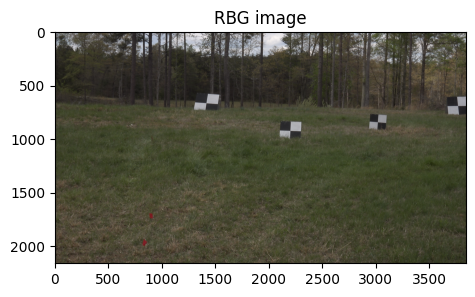

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(20, 3))

try:
  im = axes.imshow(img_bbvisright[:, :, [0,1,2]])
  axes.set_title('RBG image')

  axes.label_outer()
  plt.show()

except Exception as e:
  print(e)

Plotting the LWHSI cube

/tmp/ipykernel_6808/2103580794.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


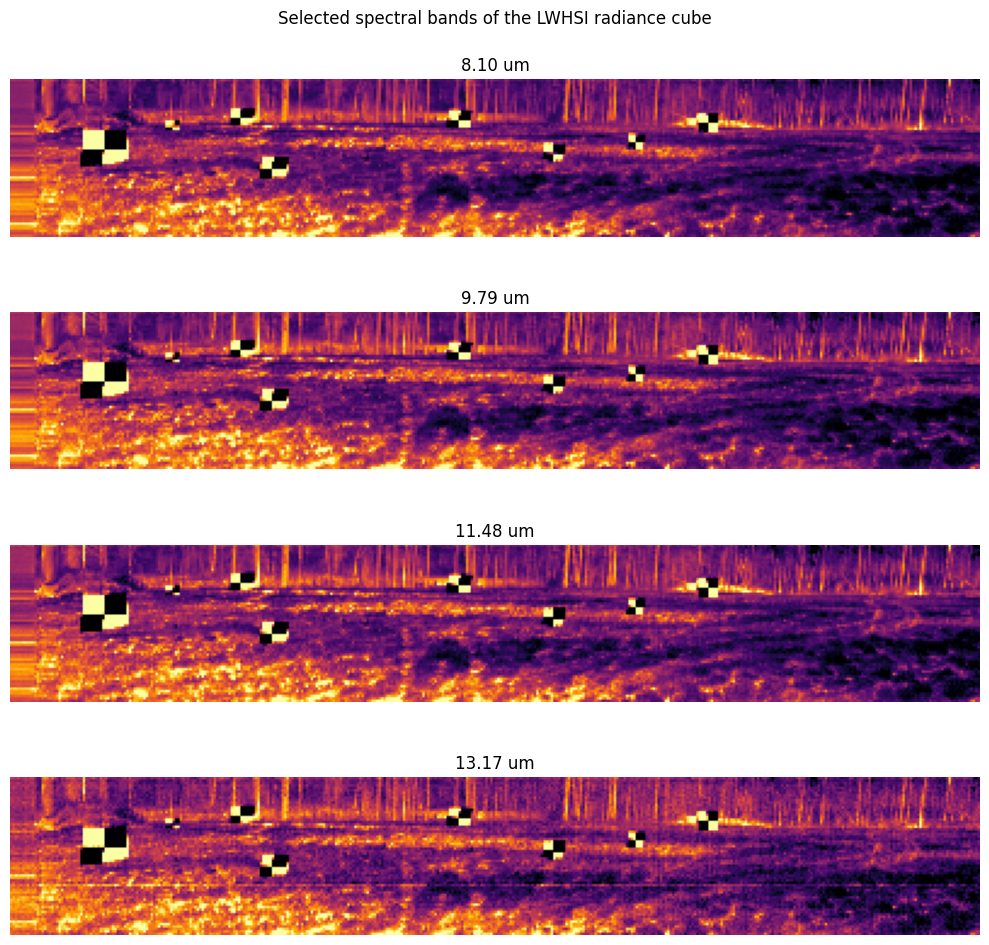

In [ ]:
try:
  if hasattr(img, 'bands') and 'wavelength' in img.metadata:
        wavelengths_um = [float(w) for w in img.metadata['wavelength']]
  else:
      num_bandas = radiance_hsi.shape[2]
      wavelengths_um = np.linspace(8.0, 12.0, num_bandas)

  band_indices = np.linspace(0, len(wavelengths_um) - 1, 4, dtype=int)
  plot_stride = 4

  fig, axes = plt.subplots(len(band_indices), 1, figsize=(10, 10))
  axes = axes.ravel()

  for ax, band_index in zip(axes, band_indices):
      band_image = radiance_hsi[::plot_stride, ::plot_stride, band_index]
      im = ax.imshow(robust_image(band_image), cmap='inferno')
      ax.set_title(f'{wavelengths_um[band_index]:.2f} um')
      ax.axis('off')

  fig.suptitle('Selected spectral bands of the LWHSI radiance cube')
  plt.tight_layout()
  plt.show()
except Exception as e:
    print(f'Error: {e}')

You can select whatever band you want (the images have a total of 256 bands)

/tmp/ipykernel_6808/2103580794.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


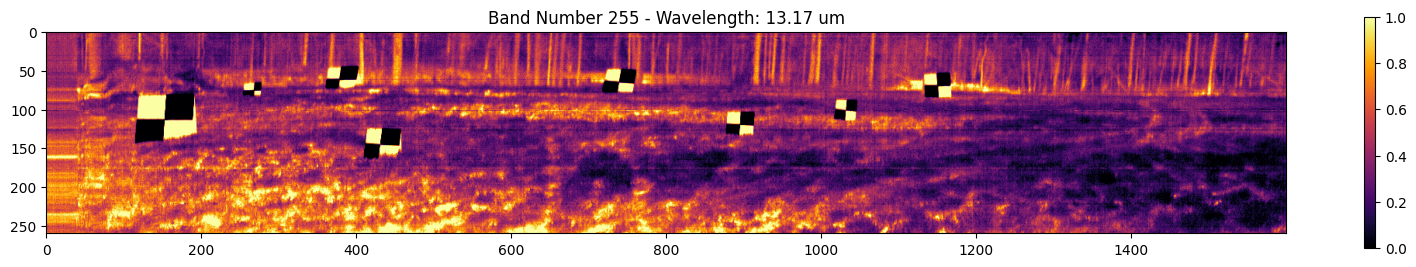

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(20, 3))

# Change the current band with this variable
selected_band = 255

try:

  im = axes.imshow(robust_image(radiance_hsi[:, :, selected_band]), cmap='inferno')
  axes.set_title(f'Band Number {selected_band} - Wavelength: {wavelengths_um[selected_band]:.2f} um')

  axes.label_outer()
  plt.colorbar(im, ax=axes)
  plt.show()

except Exception as e:
  print(e)


Select the pixels you want to plot (image shape is (260,1600,256)) on the image

In [ ]:
# Format is (x,y, # pixel, "Pixel #")

selected_pixels = [
    (180, 1050, 1, "Pixel 1"),
    (40, 250, 2, "Pixel 2"),
    (250, 370, 3, "Pixel 3"),
    (252, 273, 4, "Pixel 4")
]

selected_pixels

[(180, 1050, 1, 'Pixel 1'),
 (40, 250, 2, 'Pixel 2'),
 (250, 370, 3, 'Pixel 3'),
 (252, 273, 4, 'Pixel 4')]

Select the temperature in Kelvin

In [ ]:
# Modify the temperature value with this variable
temperature_k = 300

/tmp/ipykernel_6808/2103580794.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


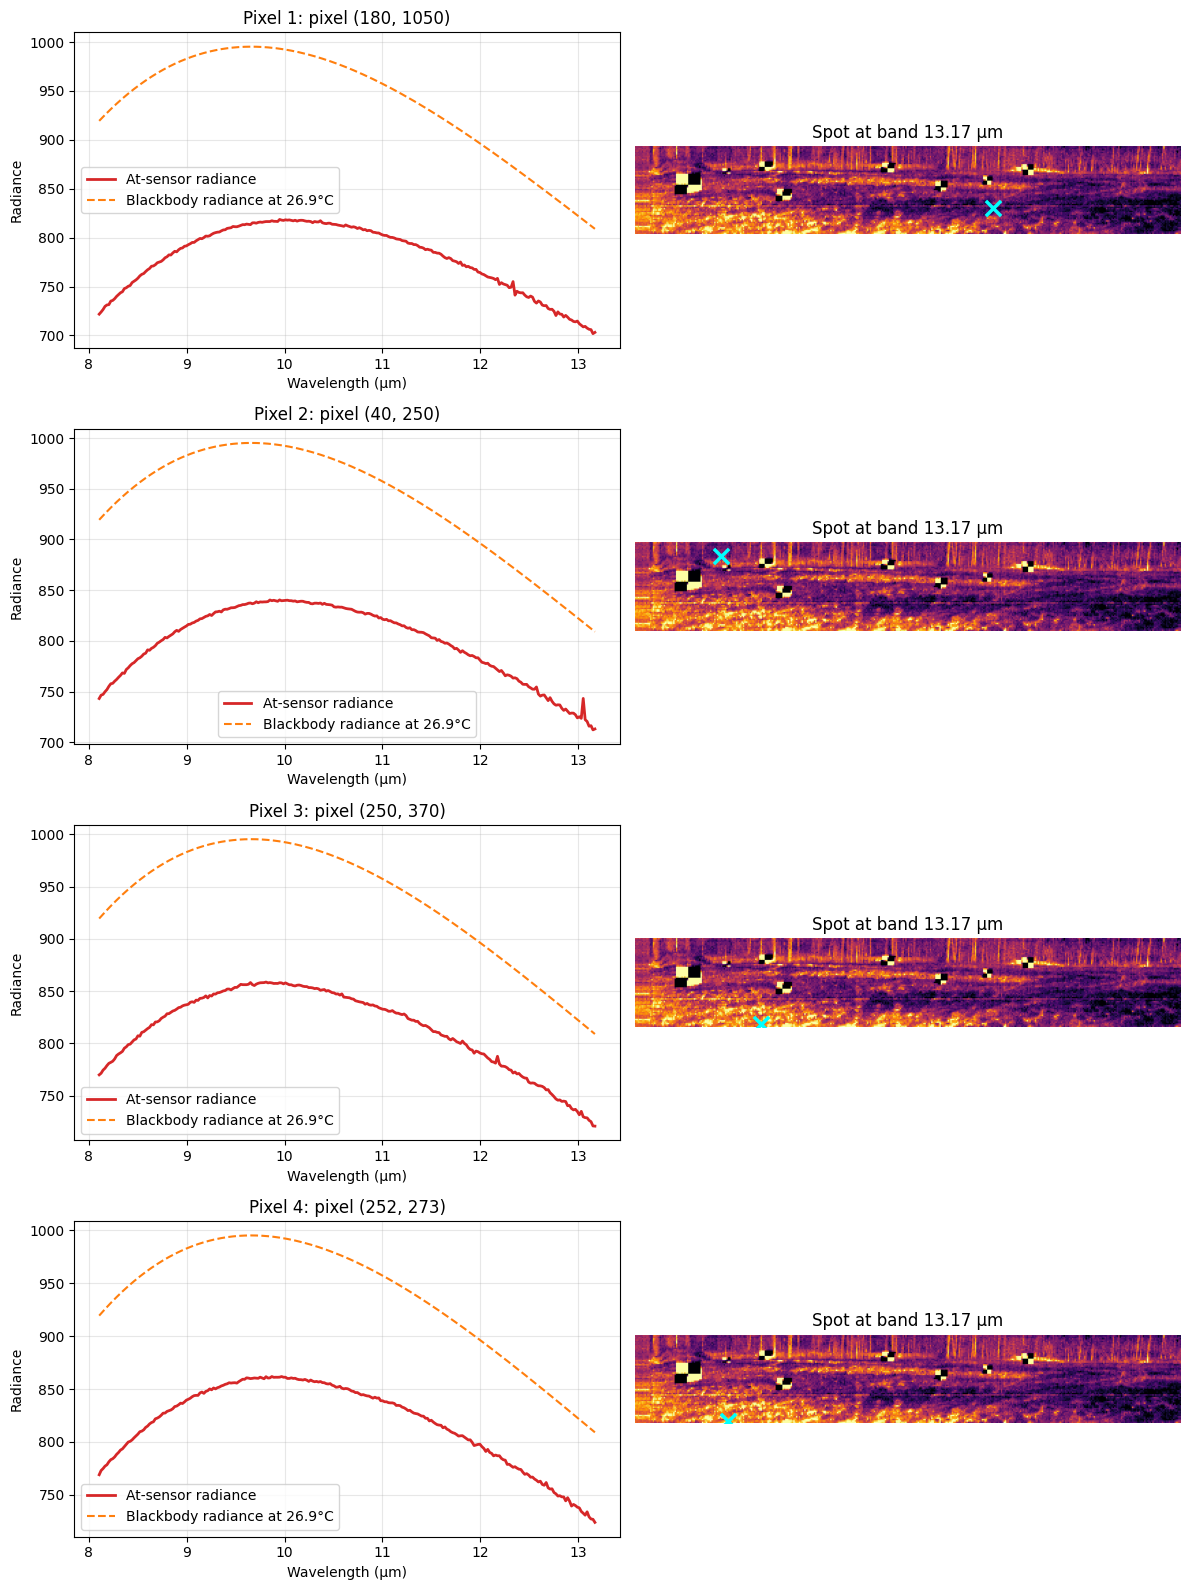

In [ ]:
wavelengths_um = np.array(wavelengths_um)
blackbody_curve=blackbody_radiance(wavelengths_um, temperature_k)

context_image = robust_image(radiance_hsi[::plot_stride, ::plot_stride, selected_band])

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, radiance_hsi[row, col, :].flatten(), color='tab:red', linewidth=2, label='At-sensor radiance')
    ax_spec.plot(wavelengths_um, blackbody_curve, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Blackbody radiance at {temperature_k-273.15:.1f}°C')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Radiance')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='inferno', aspect='equal')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Spot at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()

# LIDAR (DEPTH TRUTH)

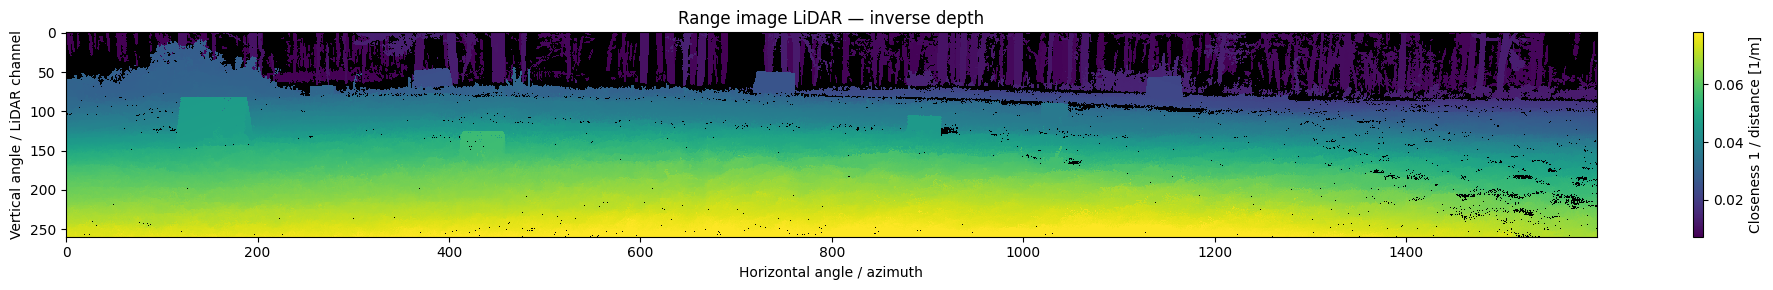

In [ ]:
plot_range_image(
      depth_truth,
      title="Range image LiDAR — inverse depth",
      crop=True,
      inverse_depth=True
  )

# EMISSIVITY TRUTH

Loading reflectance obtained in the Ecostress Spectral Library

In [ ]:
vegetation = list(Path("/content").glob("**/vegetation/*.txt"))
soil = list(Path("/content").glob("**/soil/*.txt"))
manmade = list(Path("/content").glob("**/manmade/*.txt"))

soil_wavelength, soil_emissivity = emissivity_and_wavelength(soil[47])
grass_wavelength, grass_emissivity = emissivity_and_wavelength(vegetation[8])
tree_wavelength, tree_emissivity = emissivity_and_wavelength(manmade[70])
calibrationpoints_wavelength, calibrationpoints_emissivity = emissivity_and_wavelength(manmade[53])
leaves_wavelength, leaves_emissivity = emissivity_and_wavelength(vegetation[1768])

Using K-Means to segment both the RGB and LWHSI images and get the emissivity truth map

In [ ]:
h, w, h2, w2, rgb_centers, labels_rgb, kmeans_lwhsi, labels_lwhsi_2d = segmentation_maps(5, img_bbvisright, radiance_hsi)

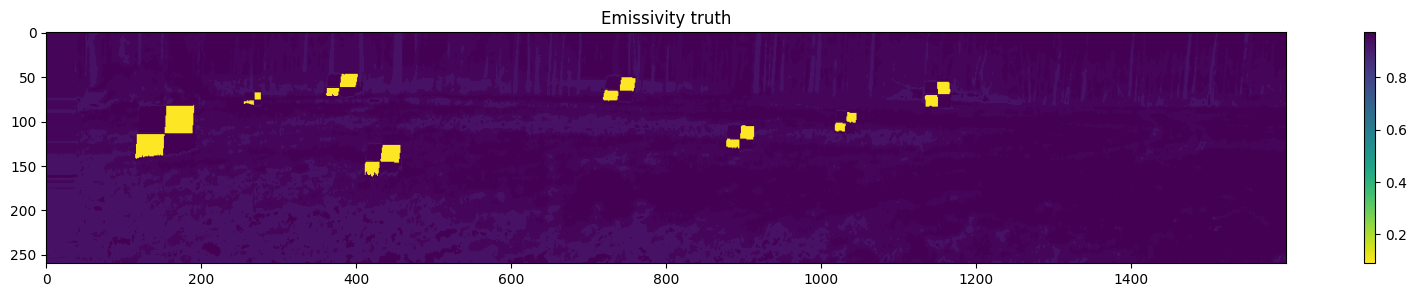

In [ ]:
emissivity_map = emissivity_truth_map(h,
                     w,
                     h2,
                     w2,
                     rgb_centers,
                     labels_rgb,
                     kmeans_lwhsi,
                     labels_lwhsi_2d,
                     calibrationpoints_emissivity,
                     soil_emissivity,
                     leaves_emissivity,
                     tree_emissivity,
                     grass_emissivity,
                     wavelengths_um,
                     calibrationpoints_wavelength,
                     soil_wavelength,
                     leaves_wavelength,
                     tree_wavelength,
                     grass_wavelength)

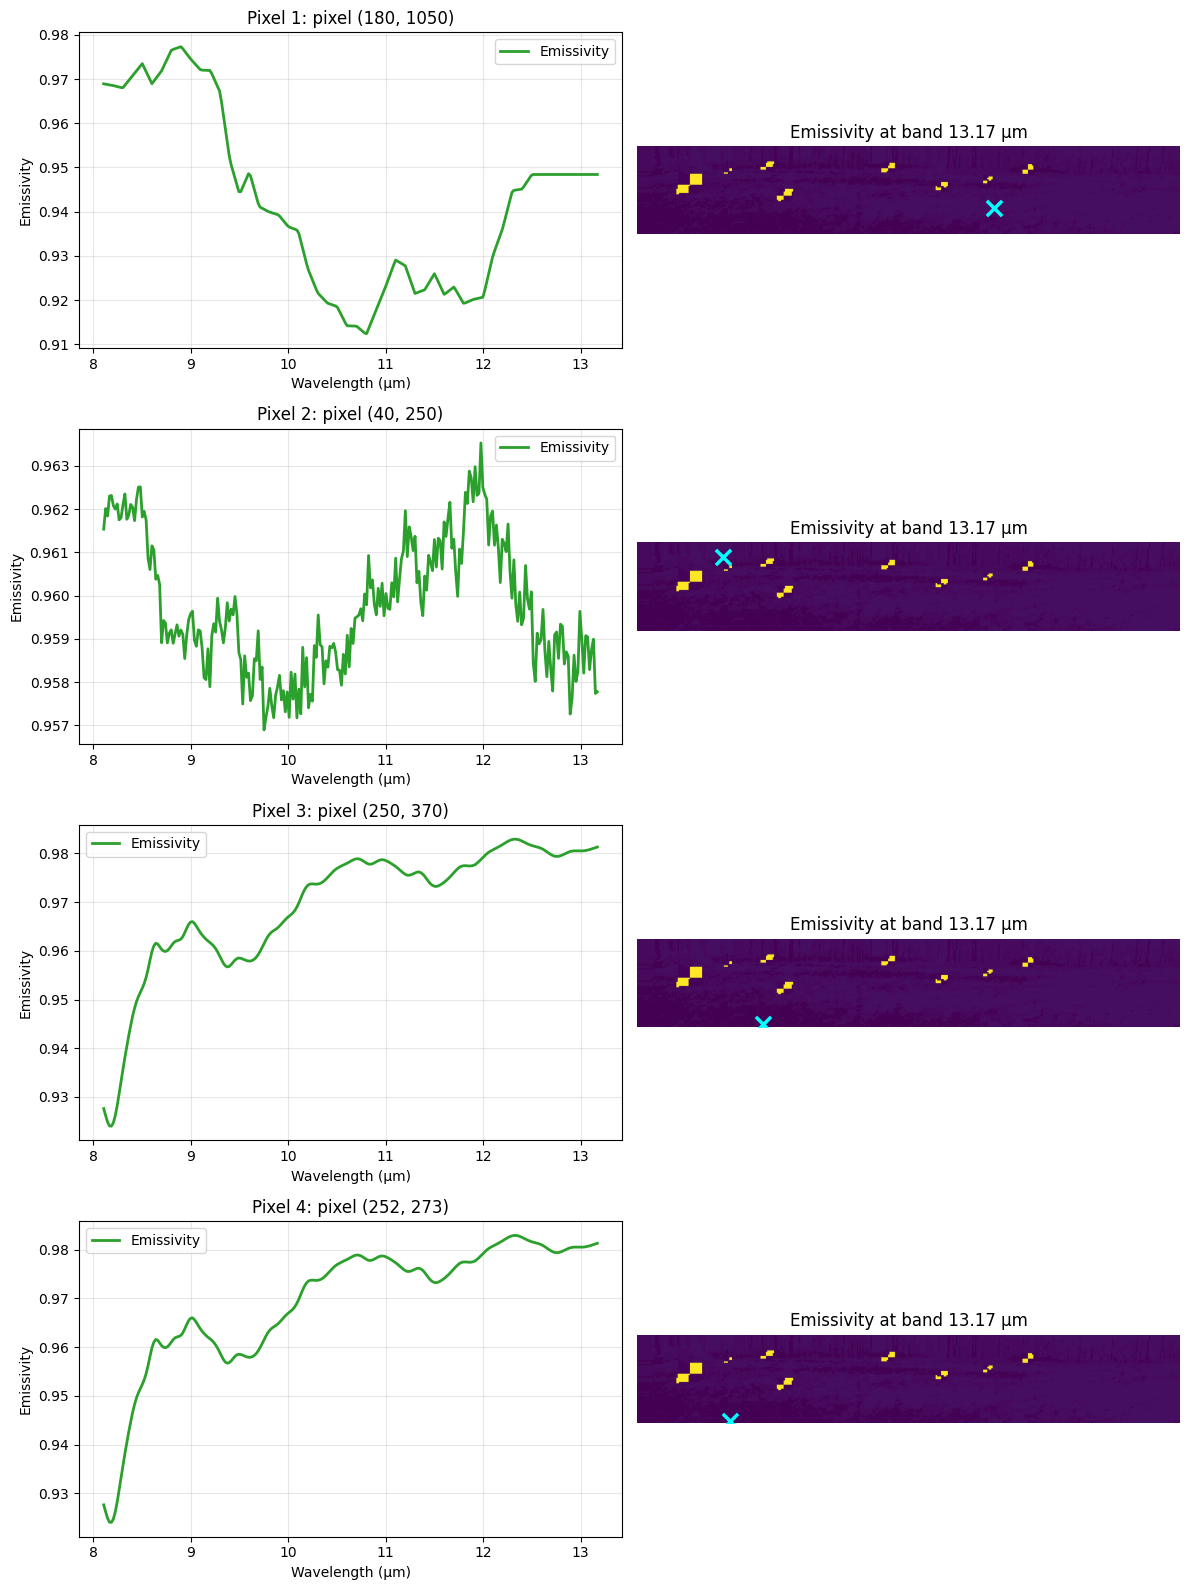

In [ ]:
wavelengths_um = np.array(wavelengths_um)
context_image = emissivity_map[::plot_stride, ::plot_stride, selected_band]

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, emissivity_map[row, col, :].flatten(), color='tab:green', linewidth=2, label='Emissivity')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Emissivity')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='viridis_r', aspect='equal')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Emissivity at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()